In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
pc_features = np.load('/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/pc_results/pca_results.npz', allow_pickle=True)
image_inf = pd.read_csv("/media/ubuntu/sda/Monkey/data/train_image_MonkeyF.csv")
mua = np.load("/media/ubuntu/sda/Monkey/data/train_MUA_MonkeyF.npy")

In [13]:
mua.shape

(22248, 503)

In [3]:
features_40d = pc_features['features_40d']

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 提取前10个PCA维度
features_10d = features_40d[:, :10]
print(f"特征维度: {features_10d.shape}")

# 进行K-means聚类，分成10个cluster
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_10d)



特征维度: (22248, 10)


In [5]:
# 根据规则定义class到cluster的映射：如果某个class有超过10张图片在某个cluster中，认为这个class属于这个cluster
threshold = 10  # 阈值：超过10张图片
classes = image_inf['class'].unique()

# 统计每个class在每个cluster中的数量
class_cluster_matrix = {}
class_to_cluster = {}  # 记录每个class属于哪个cluster

for class_name in classes:
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    class_cluster_counts = {}
    
    # 统计该class在每个cluster中的数量
    for cluster_id in range(n_clusters):
        cluster_mask = cluster_labels == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        # 计算该class在这个cluster中的数量
        count = len(np.intersect1d(class_indices, cluster_indices))
        class_cluster_counts[cluster_id] = count
    
    class_cluster_matrix[class_name] = class_cluster_counts
    
    # 找到超过阈值的cluster
    matching_clusters = [cid for cid, count in class_cluster_counts.items() if count > threshold]
    
    if len(matching_clusters) == 1:
        # 只有一个cluster超过阈值，直接分配
        class_to_cluster[class_name] = matching_clusters[0]
    elif len(matching_clusters) > 1:
        # 多个cluster超过阈值，选择数量最多的
        best_cluster = max(matching_clusters, key=lambda x: class_cluster_counts[x])
        class_to_cluster[class_name] = best_cluster
    else:
        # 没有cluster超过阈值，选择数量最多的cluster
        best_cluster = max(class_cluster_counts.items(), key=lambda x: x[1])[0]
        class_to_cluster[class_name] = best_cluster

print(f"总共 {len(classes)} 个类别")
print(f"阈值设置: 超过 {threshold} 张图片")
print(f"\n类别到Cluster的映射统计:")

# 统计每个cluster包含多少个class
cluster_class_counts = {}
for class_name, assigned_cluster in class_to_cluster.items():
    if assigned_cluster not in cluster_class_counts:
        cluster_class_counts[assigned_cluster] = []
    cluster_class_counts[assigned_cluster].append(class_name)

for cluster_id in range(n_clusters):
    count = len(cluster_class_counts.get(cluster_id, []))
    print(f"  Cluster {cluster_id}: {count} 个类别")


总共 1854 个类别
阈值设置: 超过 10 张图片

类别到Cluster的映射统计:
  Cluster 0: 148 个类别
  Cluster 1: 19 个类别
  Cluster 2: 206 个类别
  Cluster 3: 165 个类别
  Cluster 4: 116 个类别
  Cluster 5: 36 个类别
  Cluster 6: 104 个类别
  Cluster 7: 141 个类别
  Cluster 8: 915 个类别
  Cluster 9: 4 个类别


In [6]:
# 保存class到cluster的映射结果
# 创建映射DataFrame
mapping_df = pd.DataFrame({
    'class': list(class_to_cluster.keys()),
    'assigned_cluster': list(class_to_cluster.values())
})

# 添加每个class在分配到的cluster中的图片数量
image_counts = []
for class_name in mapping_df['class']:
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    assigned_cluster = class_to_cluster[class_name]
    cluster_mask = cluster_labels == assigned_cluster
    cluster_indices = np.where(cluster_mask)[0]
    count = len(np.intersect1d(class_indices, cluster_indices))
    image_counts.append(count)

mapping_df['images_in_cluster'] = image_counts
mapping_df['meets_threshold'] = mapping_df['images_in_cluster'] > threshold

# 按cluster排序
mapping_df = mapping_df.sort_values('assigned_cluster')

# 保存为CSV
mapping_output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/class_to_cluster_mapping.csv'
mapping_df.to_csv(mapping_output_path, index=False)
print(f"类别到Cluster的映射已保存到: {mapping_output_path}")

# 保存为字典格式（npz）
mapping_dict = {
    'class_to_cluster': class_to_cluster,
    'cluster_to_classes': cluster_class_counts,
    'threshold': threshold,
    'class_cluster_matrix': class_cluster_matrix
}

mapping_npz_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/class_to_cluster_mapping.npz'
np.savez(mapping_npz_path, **mapping_dict)
print(f"映射字典已保存到: {mapping_npz_path}")


类别到Cluster的映射已保存到: /media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/class_to_cluster_mapping.csv
映射字典已保存到: /media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/class_to_cluster_mapping.npz


In [7]:
# 使用UMAP进行降维可视化
try:
    import umap
    print("UMAP库已导入")
except ImportError:
    print("正在安装UMAP库...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap
    print("UMAP库安装完成")

# 使用前10个PCA维度进行UMAP降维（与K-means聚类使用的特征一致）
print(f"输入特征维度: {features_10d.shape}")

# 创建UMAP模型
reducer = umap.UMAP(n_components=3, 
                    random_state=3,
                    n_neighbors=15,
                    min_dist=0.1,
                    metric='euclidean')

# 执行降维
print("正在进行UMAP降维...")
umap_embedding = reducer.fit_transform(features_10d)
print(f"UMAP降维完成，输出维度: {umap_embedding.shape}")


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP库已导入
输入特征维度: (22248, 10)
正在进行UMAP降维...


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP降维完成，输出维度: (22248, 3)


In [8]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt

# 生成tab20颜色
n_clusters = len(np.unique(cluster_labels))
tab20_colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
# 将matplotlib RGBA转换为plotly可用的颜色格式
tab20_hex = [f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{a})' 
             for r, g, b, a in tab20_colors]

# 创建颜色映射字典
color_map = {i: tab20_hex[i] for i in range(n_clusters)}

# 创建数据
data = []
for i in range(n_clusters):
    cluster_mask = cluster_labels == i
    trace = go.Scatter3d(
        x=umap_embedding[cluster_mask, 0],
        y=umap_embedding[cluster_mask, 1],
        z=umap_embedding[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=1,
            color=tab20_hex[i],  # 使用tab20颜色
            opacity=1,
            line=dict(width=0)
        ),
        name=f'Cluster {i}',
        hovertemplate=(
            'Cluster: %{text}<br>' +
            'UMAP1: %{x:.3f}<br>' +
            'UMAP2: %{y:.3f}<br>' +
            'UMAP3: %{z:.3f}<extra></extra>'
        ),
        text=[f'Cluster {i}'] * np.sum(cluster_mask)
    )
    data.append(trace)

layout = go.Layout(
    title=dict(
        text='3D UMAP Visualization Colored by K-means Clusters',
        font=dict(size=20, family='Arial', color='black'),
        x=0.5
    ),
    scene=dict(
        xaxis=dict(
            title='UMAP 1',
            gridcolor='lightgray',
            showbackground=True,
            backgroundcolor='white'
        ),
        yaxis=dict(
            title='UMAP 2',
            gridcolor='lightgray',
            showbackground=True,
            backgroundcolor='white'
        ),
        zaxis=dict(
            title='UMAP 3',
            gridcolor='lightgray',
            showbackground=True,
            backgroundcolor='white'
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        aspectmode='data'
    ),
    legend=dict(
        title=dict(text='Clusters'),
        font=dict(size=12),
        itemsizing='constant',
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top'
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=200, t=50, b=0),
    hovermode='closest'
)

# 创建图形
fig = go.Figure(data=data, layout=layout)

# 显示图形
fig.show()


In [9]:
# 合并cluster：cluster 1和6合并，cluster 7和4合并
print("原始cluster数量:", n_clusters)
print("合并规则:")
print("  - Cluster 1 和 Cluster 6 合并")
print("  - Cluster 7 和 Cluster 4 合并")

# 创建合并后的cluster标签
merged_cluster_labels = cluster_labels.copy()

# 合并策略：将较小的cluster编号合并到较大的cluster编号
# Cluster 1 和 6 -> 合并到 1
merged_cluster_labels[merged_cluster_labels == 7] = 1

# Cluster 7 和 4 -> 合并到 4
merged_cluster_labels[merged_cluster_labels == 9] = 6
merged_cluster_labels[merged_cluster_labels == 5] = 4

# 重新映射cluster编号，使其连续（0-7）
# 原始cluster: 0, 1(包含6), 2, 3, 4(包含7), 5, 8, 9
# 需要重新映射为: 0, 1, 2, 3, 4, 5, 6, 7

# 创建映射字典
cluster_mapping = {
    0: 0,
    1: 1,  # 包含原来的1和6
    2: 2,
    3: 3,
    4: 4,  # 包含原来的4和7
    6: 5,
    8: 6
}

# 应用映射
merged_cluster_labels_renumbered = np.array([cluster_mapping[label] for label in merged_cluster_labels])

# 更新cluster数量
n_merged_clusters = len(set(merged_cluster_labels_renumbered))
print(f"\n合并后cluster数量: {n_merged_clusters}")



原始cluster数量: 10
合并规则:
  - Cluster 1 和 Cluster 6 合并
  - Cluster 7 和 Cluster 4 合并

合并后cluster数量: 7


In [10]:
# 更新class到cluster的映射（基于合并后的cluster）
# 重新计算每个class在合并后cluster中的分布
merged_class_to_cluster = {}
merged_cluster_class_counts = {i: [] for i in range(n_merged_clusters)}

for class_name in classes:
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    class_cluster_counts = {}
    
    # 统计该class在每个合并后cluster中的数量
    for cluster_id in range(n_merged_clusters):
        cluster_mask = merged_cluster_labels_renumbered == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        count = len(np.intersect1d(class_indices, cluster_indices))
        class_cluster_counts[cluster_id] = count
    
    # 找到超过阈值的cluster
    matching_clusters = [cid for cid, count in class_cluster_counts.items() if count > threshold]
    
    if len(matching_clusters) == 1:
        merged_class_to_cluster[class_name] = matching_clusters[0]
    elif len(matching_clusters) > 1:
        best_cluster = max(matching_clusters, key=lambda x: class_cluster_counts[x])
        merged_class_to_cluster[class_name] = best_cluster
    else:
        best_cluster = max(class_cluster_counts.items(), key=lambda x: x[1])[0]
        merged_class_to_cluster[class_name] = best_cluster
    
    # 添加到cluster的类别列表
    assigned_cluster = merged_class_to_cluster[class_name]
    merged_cluster_class_counts[assigned_cluster].append(class_name)



In [11]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt

# 生成tab20颜色
n_clusters = len(np.unique(merged_cluster_labels_renumbered))
tab20_colors = ["#e19368",
"#adba7d",
"#db98d5",
"#d36b6b",
"#608eb7",
"#9cbd13",
'#e3d696']
# 将matplotlib RGBA转换为plotly可用的颜色格式

# 创建颜色映射字典
color_map = {i: tab20_colors[i] for i in range(n_clusters)}

# 创建数据
data = []
for i in range(n_clusters):
    cluster_mask = merged_cluster_labels_renumbered == i
    trace = go.Scatter3d(
        x=umap_embedding[cluster_mask, 0],
        y=umap_embedding[cluster_mask, 1],
        z=umap_embedding[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=1,
            color=tab20_colors[i],  # 使用tab20颜色
            opacity=1,
            line=dict(width=0)
        ),
        name=f'Cluster {i}',
        hovertemplate=(
            'Cluster: %{text}<br>' +
            'UMAP1: %{x:.3f}<br>' +
            'UMAP2: %{y:.3f}<br>' +
            'UMAP3: %{z:.3f}<extra></extra>'
        ),
        text=[f'Cluster {i}'] * np.sum(cluster_mask)
    )
    data.append(trace)

layout = go.Layout(
    title=dict(
        text='3D UMAP Visualization Colored by K-means Clusters',
        x=0.5
    ),
    scene=dict(
        xaxis=dict(
            title='UMAP 1',
            showgrid=False,  # 去除网格线
            zeroline=False,  # 去除零线
            showbackground=False,  # 去除背景
            showticklabels=True
        ),
        yaxis=dict(
            title='UMAP 2',
            showgrid=False,  # 去除网格线
            zeroline=False,  # 去除零线
            showbackground=False,  # 去除背景
            showticklabels=True,
        ),
        zaxis=dict(
            title='UMAP 3',
            showgrid=False,  # 去除网格线
            zeroline=False,  # 去除零线
            showbackground=False,  # 去除背景
            showticklabels=True
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        aspectmode='data',
        bgcolor='white'  # 设置背景为白色
    ),
    legend=dict(
        title=dict(text='Clusters'),
        font=dict(size=12),
        itemsizing='constant',
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top'
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=200, t=50, b=0),
    hovermode='closest',
    plot_bgcolor='white',  # 设置绘图区域背景为白色
    paper_bgcolor='white'  # 设置纸张背景为白色
)

# 创建图形
fig = go.Figure(data=data, layout=layout)

# 显示图形
fig.show()

# 保存为PDF文件


In [ ]:
fig.write_image("/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/3d_umap_clusters.pdf", format='pdf',width=1200,
    height=900,
    scale=3)

In [17]:
from PIL import Image
from matplotlib.backends.backend_pdf import PdfPages
import os

# 获取PC1数据（第一列）
pc1_values = features_40d[:, 0]

# 获取图片路径
image_paths = image_inf['local_path'].values

# 按照PC1从大到小排序
sorted_indices = np.argsort(pc1_values)[::-1]  # 从大到小排序
sorted_image_paths = image_paths[sorted_indices]
sorted_pc1_values = pc1_values[sorted_indices]

print(f"总图片数: {len(sorted_image_paths)}")
print(f"PC1值范围: {sorted_pc1_values.min():.4f} 到 {sorted_pc1_values.max():.4f}")

# 设置每页的图片数量
images_per_page = 1000
# 设置网格布局：50列 x 20行 = 1000张图片
cols_per_page = 50
rows_per_page = 20

# 计算需要多少页
total_pages = (len(sorted_image_paths) + images_per_page - 1) // images_per_page
print(f"将生成 {total_pages} 页PDF")

# 设置每张图片的大小（像素）
img_size = 50  # 每张图片50x50像素
page_width = cols_per_page * img_size
page_height = rows_per_page * img_size

# 创建PDF
output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/images_sorted_by_pc1.pdf'
with PdfPages(output_path) as pdf:
    for page_idx in range(total_pages):
        print(f"正在处理第 {page_idx + 1}/{total_pages} 页...")
        
        # 创建空白页面
        fig = plt.figure(figsize=(page_width/100, page_height/100), dpi=100)
        ax = fig.add_axes([0, 0, 1, 1])
        ax.set_xlim(0, page_width)
        ax.set_ylim(0, page_height)
        ax.axis('off')
        
        # 计算当前页的图片索引范围
        start_idx = page_idx * images_per_page
        end_idx = min(start_idx + images_per_page, len(sorted_image_paths))
        page_images = sorted_image_paths[start_idx:end_idx]
        
        # 在页面上排列图片
        for img_idx, img_path in enumerate(page_images):
            row = img_idx // cols_per_page
            col = img_idx % cols_per_page
            
            x_pos = col * img_size
            y_pos = page_height - (row + 1) * img_size  # 从顶部开始
            
            try:
                # 加载图片
                if os.path.exists(img_path):
                    img = Image.open(img_path)
                    # 调整图片大小并保持纵横比
                    img.thumbnail((img_size, img_size), Image.Resampling.LANCZOS)
                    
                    # 计算居中位置
                    img_w, img_h = img.size
                    x_offset = (img_size - img_w) // 2
                    y_offset = (img_size - img_h) // 2
                    
                    # 将图片添加到页面
                    ax.imshow(img, extent=[x_pos + x_offset, x_pos + x_offset + img_w,
                                          y_pos + y_offset, y_pos + y_offset + img_h],
                            aspect='auto', interpolation='bilinear')
            except Exception as e:
                # 如果图片加载失败，跳过这张图片（继续处理下一张）
                pass
        
        # 保存页面
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0)
        plt.close(fig)

print(f"PDF已保存到: {output_path}")


总图片数: 22248
PC1值范围: -7.2629 到 73.1284
将生成 23 页PDF
正在处理第 1/23 页...
正在处理第 2/23 页...
正在处理第 3/23 页...
正在处理第 4/23 页...
正在处理第 5/23 页...
正在处理第 6/23 页...
正在处理第 7/23 页...
正在处理第 8/23 页...
正在处理第 9/23 页...
正在处理第 10/23 页...
正在处理第 11/23 页...
正在处理第 12/23 页...
正在处理第 13/23 页...
正在处理第 14/23 页...
正在处理第 15/23 页...
正在处理第 16/23 页...
正在处理第 17/23 页...
正在处理第 18/23 页...
正在处理第 19/23 页...
正在处理第 20/23 页...
正在处理第 21/23 页...
正在处理第 22/23 页...
正在处理第 23/23 页...
PDF已保存到: /media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/images_sorted_by_pc1.pdf


In [20]:
import cv2
import numpy as np
from PIL import Image
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import os

# 获取PC1值和图片路径
pc1_values = features_40d[:, 0]
image_paths = image_inf['local_path'].values
n_images = len(image_paths)

# 按照PC1值从大到小排序
sorted_indices = np.argsort(pc1_values)[::-1]  # 从大到小排序
sorted_image_paths = image_paths[sorted_indices]
sorted_pc1_values = pc1_values[sorted_indices]

print(f"总图片数: {n_images}")
print(f"PC1值范围: {sorted_pc1_values.min():.4f} 到 {sorted_pc1_values.max():.4f}")

# 设置每组的图片数量
images_per_group = 100
n_groups = (n_images + images_per_group - 1) // images_per_group
print(f"将分成 {n_groups} 组，每组约 {images_per_group} 张图片")

# 设置目标图像尺寸（用于平均计算）
target_size = (64, 64)  # 统一resize到64x64再平均，加快处理速度

# 生成PDF
output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/averaged_images_by_pc1_monkeyF.pdf'

with PdfPages(output_path) as pdf:
    for group_idx in tqdm(range(n_groups), desc="处理组"):
        # 计算当前组的索引范围
        start_idx = group_idx * images_per_group
        end_idx = min(start_idx + images_per_group, n_images)
        group_image_paths = sorted_image_paths[start_idx:end_idx]
        group_pc1_values = sorted_pc1_values[start_idx:end_idx]
        
        # 计算该组的PC1值范围
        group_pc1_min = group_pc1_values.min()
        group_pc1_max = group_pc1_values.max()
        group_pc1_mean = group_pc1_values.mean()
        
        # 初始化累加器（用于计算平均图像）
        image_sum = np.zeros((target_size[1], target_size[0], 3), dtype=np.float64)
        valid_count = 0
        
        # 读取并累加该组的所有图片
        for img_path in group_image_paths:
            try:
                if os.path.exists(img_path):
                    # 读取图片
                    img = cv2.imread(img_path)
                    if img is not None:
                        # 转换为RGB
                        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        # Resize到目标尺寸
                        img_resized = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_AREA)
                        # 累加
                        image_sum += img_resized.astype(np.float64)
                        valid_count += 1
            except Exception as e:
                continue
        
        # 计算平均图像
        if valid_count > 0:
            averaged_image = (image_sum / valid_count).astype(np.uint8)
        else:
            # 如果没有有效图片，创建黑色图像
            averaged_image = np.zeros((target_size[1], target_size[0], 3), dtype=np.uint8)
        
        # 创建图形并显示平均图像
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(averaged_image)
        ax.axis('off')
        
        # 设置标题，显示PC1值范围
        title = (f'Group {group_idx + 1}/{n_groups}\n'
                f'PC1 Range: {group_pc1_min:.2f} to {group_pc1_max:.2f} (Mean: {group_pc1_mean:.2f})\n'
                f'Images: {valid_count}/{len(group_image_paths)}')
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.close(fig)

print(f"\nPDF已保存到: {output_path}")
print(f"共生成 {n_groups} 页PDF，每页显示一组图片的平均图像")


总图片数: 22248
PC1值范围: -7.2629 到 73.1284
将分成 223 组，每组约 100 张图片


处理组: 100%|██████████| 223/223 [02:13<00:00,  1.67it/s]



PDF已保存到: /media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/averaged_images_by_pc1_monkeyF.pdf
共生成 223 页PDF，每页显示一组图片的平均图像


In [22]:
import cv2
import numpy as np
from skimage.color import rgb2lab
from tqdm import tqdm
import os

def compute_edge_lab_vector(averaged_image):
    """
    对平均图像进行处理：
    1. 去除中心32x32区域
    2. 计算剩余像素的平均RGB
    3. 转换为CIELAB空间
    返回: LAB向量 (3,)
    """
    # averaged_image已经是64x64的RGB图像，值在0-255范围
    
    # 去除中心32x32区域
    # 中心区域：从(16, 16)到(48, 48)
    mask = np.ones((64, 64), dtype=bool)
    mask[16:48, 16:48] = False  # 中心32x32区域设为False
    
    # 提取非中心区域的像素
    edge_pixels = averaged_image[mask]  # (n_pixels, 3)
    
    # 计算剩余像素的平均RGB值（归一化到0-1）
    mean_rgb = edge_pixels.mean(axis=0) / 255.0  # (3,)
    
    # 转换为CIELAB空间
    # rgb2lab需要输入为(H, W, 3)格式，值在0-1范围
    mean_rgb_reshaped = mean_rgb.reshape(1, 1, 3)
    mean_lab = rgb2lab(mean_rgb_reshaped)[0, 0, :]  # (3,) L, a, b
    
    return mean_lab

# 获取PC1值和图片路径
pc1_values = features_40d[:, 0]
image_paths = image_inf['local_path'].values
n_images = len(image_paths)

# 按照PC1值从大到小排序
sorted_indices = np.argsort(pc1_values)[::-1]  # 从大到小排序
sorted_image_paths = image_paths[sorted_indices]
sorted_pc1_values = pc1_values[sorted_indices]

print(f"总图片数: {n_images}")
print(f"PC1值范围: {sorted_pc1_values.min():.4f} 到 {sorted_pc1_values.max():.4f}")

# 设置每组的图片数量（与Cell 21保持一致）
images_per_group = 100
n_groups = (n_images + images_per_group - 1) // images_per_group
print(f"将分成 {n_groups} 组，每组约 {images_per_group} 张图片")

# 设置目标图像尺寸（用于平均计算）
target_size = (64, 64)  # 统一resize到64x64再平均

# 存储每组的平均图像和LAB向量
averaged_images = []
lab_vectors = []
group_pc1_info = []

print(f"\n开始计算 {n_groups} 组平均图像并提取LAB向量...")

for group_idx in tqdm(range(n_groups), desc="处理组"):
    # 计算当前组的索引范围
    start_idx = group_idx * images_per_group
    end_idx = min(start_idx + images_per_group, n_images)
    group_image_paths = sorted_image_paths[start_idx:end_idx]
    group_pc1_values = sorted_pc1_values[start_idx:end_idx]
    
    # 计算该组的PC1值范围
    group_pc1_min = group_pc1_values.min()
    group_pc1_max = group_pc1_values.max()
    group_pc1_mean = group_pc1_values.mean()
    
    # 初始化累加器（用于计算平均图像）
    image_sum = np.zeros((target_size[1], target_size[0], 3), dtype=np.float64)
    valid_count = 0
    
    # 读取并累加该组的所有图片
    for img_path in group_image_paths:
        try:
            if os.path.exists(img_path):
                # 读取图片
                img = cv2.imread(img_path)
                if img is not None:
                    # 转换为RGB
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Resize到目标尺寸
                    img_resized = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_AREA)
                    # 累加
                    image_sum += img_resized.astype(np.float64)
                    valid_count += 1
        except Exception as e:
            continue
    
    # 计算平均图像
    if valid_count > 0:
        averaged_image = (image_sum / valid_count).astype(np.uint8)
        
        # 对平均图像进行处理：去除中心32x32，计算LAB向量
        lab_vector = compute_edge_lab_vector(averaged_image)
        
        averaged_images.append(averaged_image)
        lab_vectors.append(lab_vector)
        group_pc1_info.append({
            'min': group_pc1_min,
            'max': group_pc1_max,
            'mean': group_pc1_mean,
            'count': valid_count
        })
    else:
        # 如果没有有效图片，跳过
        continue

# 转换为numpy数组
lab_vectors_array = np.array(lab_vectors)  # (n_groups, 3)
group_pc1_means = np.array([info['mean'] for info in group_pc1_info])

print(f"\n完成！共处理 {len(lab_vectors)} 组平均图像")
print(f"LAB向量形状: {lab_vectors_array.shape}")  # (n_groups, 3)
print(f"\nLAB值范围:")
print(f"  L (亮度): {lab_vectors_array[:, 0].min():.2f} 到 {lab_vectors_array[:, 0].max():.2f}")
print(f"  a (绿-红): {lab_vectors_array[:, 1].min():.2f} 到 {lab_vectors_array[:, 1].max():.2f}")
print(f"  b (蓝-黄): {lab_vectors_array[:, 2].min():.2f} 到 {lab_vectors_array[:, 2].max():.2f}")


np.save('/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyN/averaged_edge_lab_vectors.npy', lab_vectors_array)
np.save('/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyN/averaged_group_pc1_means.npy', group_pc1_means)


总图片数: 22248
PC1值范围: -7.2629 到 73.1284
将分成 223 组，每组约 100 张图片

开始计算 223 组平均图像并提取LAB向量...


处理组: 100%|██████████| 223/223 [01:55<00:00,  1.94it/s]


完成！共处理 223 组平均图像
LAB向量形状: (223, 3)

LAB值范围:
  L (亮度): 44.95 到 64.55
  a (绿-红): -2.92 到 3.86
  b (蓝-黄): 4.69 到 14.60


PDF已保存到: /media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/L_b_scatter_with_ci.pdf


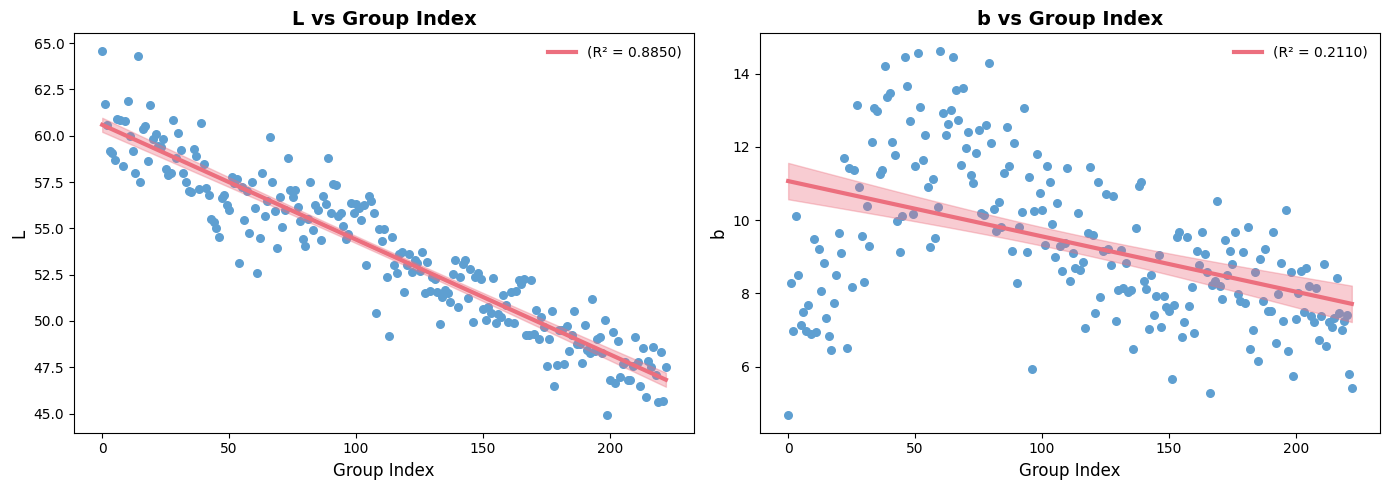

In [27]:
from sklearn.metrics import r2_score
from scipy import stats

x = np.arange(len(lab_vectors_array))  # range(223): 0 到 222
L_values = lab_vectors_array[:, 0]  # L值
b_values = lab_vectors_array[:, 2]  # b值

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_values, y_label in zip([ax1, ax2], [L_values, b_values], ['L', 'b']):
    ax.scatter(x, y_values, alpha=1, s=30, color='#5E9FD1')

    slope, intercept = np.polyfit(x, y_values, 1)
    y_fit = slope * x + intercept
    r2 = r2_score(y_values, y_fit)

    residuals = y_values - y_fit
    n = len(x)
    mse = np.sum(residuals**2) / (n - 2)

    se_fit = np.sqrt(mse * (1/n + (x - np.mean(x))**2 / np.sum((x - np.mean(x))**2)))
    t_critical = stats.t.ppf(0.975, n - 2)

    ci_upper = y_fit + t_critical * se_fit
    ci_lower = y_fit - t_critical * se_fit

    ax.fill_between(x, ci_lower, ci_upper, alpha=0.35, color='#EC6F7E')
    ax.plot(x, y_fit, linewidth=3, label=f'(R² = {r2:.4f})', color='#EC6F7E')

    ax.set_xlabel('Group Index', fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(f'{y_label} vs Group Index', fontsize=14, fontweight='bold')
    ax.legend(frameon=False)

plt.tight_layout()

output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10_monkeyF/L_b_scatter_with_ci.pdf'
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"PDF已保存到: {output_path}")

plt.show()